In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.Util import util
from matplotlib.patches import Ellipse

# ===========================================================================
# 1. LOAD AND TRANSFORM DATA (Right-Handed Coordinate Grid)
# ===========================================================================
c1 = pd.read_csv('cluster1.csv').sort_values('RAcen').reset_index(drop=True)
c2 = pd.read_csv('cluster2.csv').sort_values('RAcen').reset_index(drop=True)
s1 = pd.read_csv('system_1.412.csv')
s2 = pd.read_csv('system_1.407.csv')  # Uses all 6 observed lensed coordinates

ra_ref, dec_ref = 180.162, -1.451

def to_arcsec(ra, dec):
    # Flipped to standard right-handed Cartesian grid (West-is-Right, East-is-Left)
    x = -(ra - ra_ref) * 3600 * np.cos(np.radians(dec_ref))
    y = (dec - dec_ref) * 3600
    return x, y

x_img1, y_img1 = to_arcsec(s1['RA'], s1['DEC'])
x_img2, y_img2 = to_arcsec(s2['RA'], s2['DEC'])

# ===========================================================================
# COSMOLOGY CONFIGURATION (Change parameters here to test alternative universes)
# ===========================================================================
from astropy.cosmology import FlatLambdaCDM

# Define your cosmology. You can vary these to see the impact on predicted images:
# - H0: Hubble constant (km/s/Mpc) [standard value is 70.0]
# - Om0: Dimensionless matter density parameter at z=0 [standard value is 0.3]
# - Ob0: Baryonic matter density parameter [standard value is 0.05]
custom_cosmo = FlatLambdaCDM(name="Planck18", H0=67.66, Om0=0.30966, Tcmb0=2.7255, Neff=3.046, Ob0=0.04897, m_nu=[0.,   0.,   0.06])

# ===========================================================================
# 2. SETUP MULTI-PLANE LENS MODEL (SERSICs + DM Halos + External Shears)
# ===========================================================================
# We model 22 elliptical Sersics, 3 elliptical NFW halos (two for Cluster 1, one for Cluster 2), and 2 external shears
lens_model_list = ['SERSIC_ELLIPSE_POTENTIAL'] * 22 + ['NFW_ELLIPSE_POTENTIAL'] * 3 + ['SHEAR'] * 2

# Project all components onto their respective cluster planes:
# Galaxies share cluster planes, NFW halos are at [z1, z1, z2], shears are at [z1, z2]
lens_redshift_list = [0.268] * len(c1) + [0.327] * len(c2) + [0.268, 0.268, 0.327] + [0.268, 0.327]
# We pass the custom cosmology object into both multi-plane lens models
lensModel_s1 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.412,cosmo=custom_cosmo)
# S2 model represents the background source at z=1.407
lensModel_s2 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.407,cosmo=custom_cosmo)

rs1, rs2 = 13.56, 9.23   # Fixed scale radii of dark matter halos from cosmological masses

# Pre-calculate NFW coordinates centered on the three cluster cores
xc_n1_a, yc_n1_a = to_arcsec(c1.loc[2, 'RAcen'], c1.loc[2, 'Deccen'])   # Cluster 1 Core A (Galaxy 03 center)
xc_n1_b, yc_n1_b = to_arcsec(c1.loc[8, 'RAcen'], c1.loc[8, 'Deccen'])   # Cluster 1 Core B (Galaxy 09 center)
xc_n2, yc_n2 = to_arcsec(c2.loc[7, 'RAcen'], c2.loc[7, 'Deccen'])       # Cluster 2 Core (Galaxy 15 center)

def get_kwargs_lens(params):
    (
        k_m1, k_m2, k_m3, k_b1, k_b2,              # Sersic amplitudes (5)
        alpha_rs1a, alpha_rs1b, alpha_rs2,         # NFW halo amplitudes (3)
        e1_n1a, e2_n1a, e1_n1b, e2_n1b, e1_n2, e2_n2,# NFW halo ellipticities (6)
        g1_s1, g2_s1, g1_s2, g2_s2,                # External shears (4)
        e1_m1, e2_m1, e1_m2, e2_m2, e1_m3, e2_m3   # Massive galaxy ellipticities (6)
    ) = params
    
    kwargs_lens = []
    
    # Plane 1: Cluster 1 Sersics (z=0.268)
    for i, row in c1.iterrows():
        x, y = to_arcsec(row['RAcen'], row['Deccen'])
        if i == 2:
            kwargs_lens.append({'k_eff': k_m1, 'R_sersic': 3.5, 'n_sersic': 4.0, 'e1': e1_m1, 'e2': e2_m1, 'center_x': x, 'center_y': y})
        elif i == 8:
            kwargs_lens.append({'k_eff': k_m2, 'R_sersic': 3.5, 'n_sersic': 4.0, 'e1': e1_m2, 'e2': e2_m2, 'center_x': x, 'center_y': y})
        else:
            kwargs_lens.append({'k_eff': k_b1, 'R_sersic': 0.8, 'n_sersic': 4.0, 'e1': 0.0, 'e2': 0.0, 'center_x': x, 'center_y': y})
            
    # Plane 2: Cluster 2 Sersics (z=0.327)
    for i, row in c2.iterrows():
        x, y = to_arcsec(row['RAcen'], row['Deccen'])
        if i == 7:
            kwargs_lens.append({'k_eff': k_m3, 'R_sersic': 3.0, 'n_sersic': 4.0, 'e1': e1_m3, 'e2': e2_m3, 'center_x': x, 'center_y': y})
        else:
            kwargs_lens.append({'k_eff': k_b2, 'R_sersic': 0.6, 'n_sersic': 4.0, 'e1': 0.0, 'e2': 0.0, 'center_x': x, 'center_y': y})
            
    # Appended Cluster 1 smooth dark matter halo A (z=0.268, centered on Galaxy 03)
    kwargs_lens.append({'Rs': rs1, 'alpha_Rs': alpha_rs1a, 'e1': e1_n1a, 'e2': e2_n1a, 'center_x': xc_n1_a, 'center_y': yc_n1_a})
    
    # Appended Cluster 1 smooth dark matter halo B (z=0.268, centered on Galaxy 09)
    kwargs_lens.append({'Rs': rs1, 'alpha_Rs': alpha_rs1b, 'e1': e1_n1b, 'e2': e2_n1b, 'center_x': xc_n1_b, 'center_y': yc_n1_b})
    
    # Appended Cluster 2 smooth dark matter halo (z=0.327, centered on Galaxy 15)
    kwargs_lens.append({'Rs': rs2, 'alpha_Rs': alpha_rs2, 'e1': e1_n2, 'e2': e2_n2, 'center_x': xc_n2, 'center_y': yc_n2})
    
    # External Shear on Plane 1 (z=0.268) centered on Halo A
    kwargs_lens.append({'gamma1': g1_s1, 'gamma2': g2_s1, 'ra_0': xc_n1_a, 'dec_0': yc_n1_a})
    
    # External Shear on Plane 2 (z=0.327) centered on Halo C
    kwargs_lens.append({'gamma1': g1_s2, 'gamma2': g2_s2, 'ra_0': xc_n2, 'dec_0': yc_n2})
    
    return kwargs_lens

# ===========================================================================
# 3. OBJECTIVE FUNCTION (Minimize Coordinate Spread)
# ===========================================================================
sigma_img = 0.004

def objective(params):
    # 1. Vectorized check: Ensure the first 8 physical mass/potential amplitudes are strictly positive
    if np.any(params[:8] <= 0):
        return 1e10
        
    # 2. Vectorized check: Keep ellipticity parameters (indices 8-13 and 18-23) within physical boundaries (|e| <= 0.8)
    if np.any(np.abs(params[8:14]) > 0.8) or np.any(np.abs(params[18:]) > 0.8):
        return 1e10
        
    # 3. Vectorized check: Keep external shear parameters (indices 14-17) within physical tidal boundaries (|g| <= 0.4)
    if np.any(np.abs(params[14:18]) > 0.4):
        return 1e10
        
    kwargs_lens = get_kwargs_lens(params)
    src1_ra, src1_dec = lensModel_s1.ray_shooting(x_img1, y_img1, kwargs_lens)
    src2_ra, src2_dec = lensModel_s2.ray_shooting(x_img2, y_img2, kwargs_lens)
    
    chi2_1 = (np.sum((src1_ra - np.mean(src1_ra))**2) + np.sum((src1_dec - np.mean(src1_dec))**2)) / (sigma_img**2)
    chi2_2 = (np.sum((src2_ra - np.mean(src2_ra))**2) + np.sum((src2_dec - np.mean(src2_dec))**2)) / (sigma_img**2)
    
    return 0.5 * (chi2_1 + chi2_2)

# ===========================================================================
# 4. TWO-STAGE GLOBAL + LOCAL OPTIMIZATION (Differential Evolution + BFGS)
# ===========================================================================
# Widened bounds to prevent parameter pinning at the edges
# Expanded ONLY the bounds for parameters that were pinned/near the edges to avoid local minima
bounds = [
    (0.1, 5.0),     # k_m1: Cluster 1 Massive 1
    (0.1, 5.0),     # k_m2: Cluster 1 Massive 2
    (0.1, 5.0),     # k_m3: Cluster 2 Massive
    (0.01, 2.0),    # k_b1: Cluster 1 Standards
    (0.01, 2.0),    # k_b2: Cluster 2 Standards
    (0.01, 10.5),   # alpha_rs1a: C1 DM Halo A Amplitude
    (0.01, 10.5),   # alpha_rs1b: C1 DM Halo B Amplitude
    (0.01, 10.5),   # alpha_rs2: C2 DM Halo Amplitude
    (-0.5, 0.5),    # e1_n1a: C1 DM Halo A e1
    (-0.5, 0.5),    # e2_n1a: C1 DM Halo A e2
    (-0.5, 0.5),    # e1_n1b: C1 DM Halo B e1
    (-0.5, 0.5),    # e2_n1b: C1 DM Halo B e2
    (-0.5, 0.5),    # e1_n2: C2 DM Halo e1
    (-0.5, 0.5),    # e2_n2: C2 DM Halo e2
    (-0.2, 0.2),    # g1_s1: C1 Shear gamma1
    (-0.2, 0.2),    # g2_s1: C1 Shear gamma2
    (-0.2, 0.2),    # g1_s2: C2 Shear gamma1
    (-0.2, 0.2),    # g2_s2: C2 Shear gamma2
    (-0.5, 0.5),    # e1_m1: Massive 1 e1
    (-0.5, 0.5),    # e2_m1: Massive 1 e2
    (-0.5, 0.5),    # e1_m2: Massive 2 e1
    (-0.5, 0.5),    # e2_m2: Massive 2 e2
    (-0.5, 0.5),    # e1_m3: Massive 3 e1
    (-0.5, 0.5)     # e2_m3: Massive 3 e2
]

print("--- STAGE 1: Differential Evolution Global Search (Escaping Local Minima) ---")
res_de = differential_evolution(objective, bounds, strategy='best1bin', maxiter=120, popsize=15, tol=1e-3, seed=42)

print("--- STAGE 2: BFGS Local Refinement (High-Precision Convergence) ---")
res_opt = minimize(objective, res_de.x, method='BFGS', tol=1e-6)

# ===========================================================================
# 5. COMPUTE NUMERICAL HESSIAN FOR EXACT MASS UNCERTAINTIES
# ===========================================================================
def compute_hessian(func, x, eps=1e-3):
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus, x_minus = np.array(x, dtype=float), np.array(x, dtype=float)
                x_plus[i] += eps; x_minus[i] -= eps
                hess[i, i] = (func(x_plus) - 2 * func(x) + func(x_minus)) / (eps**2)
            else:
                x_pp, x_pm, x_mp, x_mm = [np.array(x, dtype=float) for _ in range(4)]
                x_pp[i] += eps; x_pp[j] += eps
                x_pm[i] += eps; x_pm[j] -= eps
                x_mp[i] -= eps; x_mp[j] += eps
                x_mm[i] -= eps; x_mm[j] -= eps
                hess[i, j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps**2)
    return hess

print("--- Calculating parameter uncertainties from the Hessian ---")
hessian_matrix = compute_hessian(objective, res_opt.x)
cov_matrix = np.linalg.inv(hessian_matrix)
uncertainties = np.sqrt(np.diag(cov_matrix))

# Unpack parameter outputs
(
    k_m1, k_m2, k_m3, k_b1, k_b2,
    alpha_rs1a, alpha_rs1b, alpha_rs2,
    e1_n1a, e2_n1a, e1_n1b, e2_n1b, e1_n2, e2_n2,
    g1_s1, g2_s1, g1_s2, g2_s2,
    e1_m1, e2_m1, e1_m2, e2_m2, e1_m3, e2_m3
) = res_opt.x

(
    u_m1, u_m2, u_m3, u_b1, u_b2,
    u_n1a, u_n1b, u_n2,
    ue1_n1a, ue2_n1a, ue1_n1b, ue2_n1b, ue1_n2, ue2_n2,
    ug1_s1, ug2_s1, ug1_s2, ug2_s2,
    ue1_m1, ue2_m1, ue1_m2, ue2_m2, ue1_m3, ue2_m3
) = uncertainties

kwargs_lens_opt = get_kwargs_lens(res_opt.x)

# Recovered Source Plane Coordinates and Residual Spreads
src1_ra_opt, src1_dec_opt = lensModel_s1.ray_shooting(x_img1, y_img1, kwargs_lens_opt)
src2_ra_opt, src2_dec_opt = lensModel_s2.ray_shooting(x_img2, y_img2, kwargs_lens_opt)

spread1_opt = np.sqrt(np.std(src1_ra_opt)**2 + np.std(src1_dec_opt)**2)
spread2_opt = np.sqrt(np.std(src2_ra_opt)**2 + np.std(src2_dec_opt)**2)

# Helper function to convert e1, e2 back to axis ratio q and angle (deg)
def e1e2_to_qphi(e1, e2):
    e = np.sqrt(e1**2 + e2**2)
    if e == 0: return 1.0, 0.0
    q = (1.0 - e) / (1.0 + e)
    phi = 0.5 * np.arctan2(e2, e1)
    return q, np.degrees(phi)

# ===========================================================================
# 6. PRINT RESULTS
# ===========================================================================
print("\n" + "="*45 + "\n=== OPTIMAL MASS DISTRIBUTION RESULTS ===\n" + "="*45)
print(f"Galaxy Cluster 1 Massive 1 (Galaxy 03): k_eff = {k_m1:.4f} ± {u_m1:.4f}, e1 = {e1_m1:.4f} ± {ue1_m1:.4f}, e2 = {e2_m1:.4f} ± {ue2_m1:.4f}")
print(f"Galaxy Cluster 1 Massive 2 (Galaxy 09): k_eff = {k_m2:.4f} ± {u_m2:.4f}, e1 = {e1_m2:.4f} ± {ue1_m2:.4f}, e2 = {e2_m2:.4f} ± {ue2_m2:.4f}")
print(f"Galaxy Cluster 2 Massive   (Galaxy 15): k_eff = {k_m3:.4f} ± {u_m3:.4f}, e1 = {e1_m3:.4f} ± {ue1_m3:.4f}, e2 = {e2_m3:.4f} ± {ue2_m3:.4f}")
print(f"Galaxy Cluster 1 Standard Galaxies:   k_eff = {k_b1:.4f} ± {u_b1:.4f}")
print(f"Galaxy Cluster 2 Standard Galaxies:   k_eff = {k_b2:.4f} ± {u_b2:.4f}")
print(f"Galaxy Cluster 1 DM Halo A alpha_Rs:   alpha_Rs = {alpha_rs1a:.4f} ± {u_n1a:.4f}, e1 = {e1_n1a:.4f} ± {ue1_n1a:.4f}, e2 = {e2_n1a:.4f} ± {ue2_n1a:.4f}")
print(f"Galaxy Cluster 1 DM Halo B alpha_Rs:   alpha_Rs = {alpha_rs1b:.4f} ± {u_n1b:.4f}, e1 = {e1_n1b:.4f} ± {ue1_n1b:.4f}, e2 = {e2_n1b:.4f} ± {ue2_n1b:.4f}")
print(f"Galaxy Cluster 2 DM Halo alpha_Rs:    alpha_Rs = {alpha_rs2:.4f} ± {u_n2:.4f}, e1 = {e1_n2:.4f} ± {ue1_n2:.4f}, e2 = {e2_n2:.4f} ± {ue2_n2:.4f}")
print(f"Galaxy Cluster 1 External Shear:      gamma1 = {g1_s1:.4f} ± {ug1_s1:.4f}, gamma2 = {g2_s1:.4f} ± {ug2_s1:.4f}")
print(f"Galaxy Cluster 2 External Shear:      gamma1 = {g1_s2:.4f} ± {ug1_s2:.4f}, gamma2 = {g2_s2:.4f} ± {ug2_s2:.4f}")

print("\n" + "="*45 + "\n=== ORIGINAL SOURCE PLANE RECOVERED POSITIONS ===\n" + "="*45)
print(f"Source 1 (z=1.412) Recovered: RA_arcsec = {np.mean(src1_ra_opt):.4f}, Dec_arcsec = {np.mean(src1_dec_opt):.4f}")
print(f"Source 1 Residual Spread (arcsec): {spread1_opt:.5f}")
print(f"Source 2 (z=1.407) Recovered: RA_arcsec = {np.mean(src2_ra_opt):.4f}, Dec_arcsec = {np.mean(src2_dec_opt):.4f}")
print(f"Source 2 Residual Spread (arcsec): {spread2_opt:.5f}")

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


--- STAGE 1: Differential Evolution Global Search (Escaping Local Minima) ---
--- STAGE 2: BFGS Local Refinement (High-Precision Convergence) ---
--- Calculating parameter uncertainties from the Hessian ---

=== OPTIMAL MASS DISTRIBUTION RESULTS ===
Galaxy Cluster 1 Massive 1 (Galaxy 03): k_eff = 0.0000 ± 0.0000, e1 = 0.1306 ± nan, e2 = -0.3619 ± 0.1263
Galaxy Cluster 1 Massive 2 (Galaxy 09): k_eff = 1.6736 ± nan, e1 = 0.3777 ± 0.0001, e2 = -0.4544 ± 0.0006
Galaxy Cluster 2 Massive   (Galaxy 15): k_eff = 0.6582 ± 0.0022, e1 = -0.6670 ± nan, e2 = -0.1837 ± 0.0008
Galaxy Cluster 1 Standard Galaxies:   k_eff = 0.0063 ± 0.0073
Galaxy Cluster 2 Standard Galaxies:   k_eff = 0.5098 ± 0.0172
Galaxy Cluster 1 DM Halo A alpha_Rs:   alpha_Rs = 7.9631 ± 0.0067, e1 = -0.4024 ± 0.0026, e2 = -0.0792 ± 0.0008
Galaxy Cluster 1 DM Halo B alpha_Rs:   alpha_Rs = 9.0363 ± 0.0019, e1 = -0.5281 ± 0.0007, e2 = -0.0677 ± 0.0001
Galaxy Cluster 2 DM Halo alpha_Rs:    alpha_Rs = 8.9035 ± 0.0103, e1 = -0.1895 ± 0.

/tmp/ipykernel_4998/16087503.py:196: RuntimeWarning: invalid value encountered in sqrt
  uncertainties = np.sqrt(np.diag(cov_matrix))



=== FORWARD MODELING PREDICTED IMAGE POSITIONS ===

System 1 (z=1.412) Forward Model Comparison:
Image  | Observed (RA, DEC)     | Predicted (RA, DEC)    | Offset (arcsec)
---------------------------------------------------------------------------
1a     | (29.0547, -27.7940) | (30.0123, -26.9369) | 1.28519
1b     | (31.0700, -25.4150) | (30.0123, -26.9369) | 1.85335
1c     | (-12.9214, 4.7120) | (-11.5125, 3.2459) | 2.03326
1d     | (-5.8931, 11.6940) | (-3.7735, 12.8914) | 2.43446
1e     | (9.2670, 3.5220) | (10.2358, 2.6470) | 1.30544
Average System 1 Position Offset: 1.78234 arcsec

System 2 (z=1.407) Forward Model Comparison:
Image  | Observed (RA, DEC)     | Predicted (RA, DEC)    | Offset (arcsec)
---------------------------------------------------------------------------
2a     | (23.7134, -34.3410) | (24.5606, -33.7301) | 1.04445
2b     | (25.5218, -6.5400) | (26.2502, -7.4288) | 1.14912
2f     | (-12.1611, 13.9450) | (-13.8967, 19.3582) | 5.68460
2c     | (-9.3570, 20.2140) 

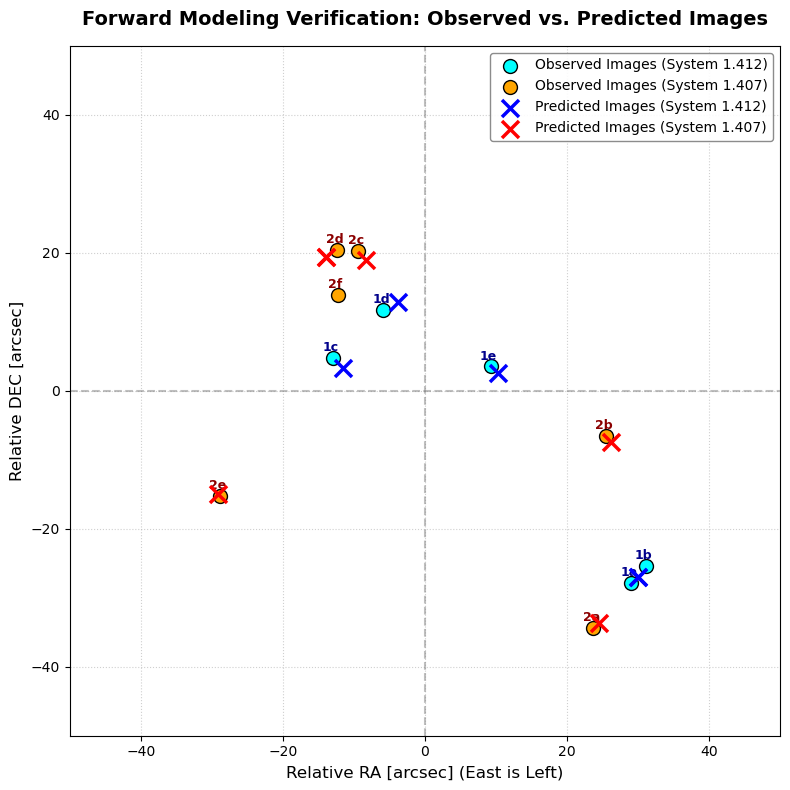

In [2]:
# ===========================================================================
# 7. GRAPHING (Visualizing Sersics + Elliptical DM Halos + Shears)
# ===========================================================================
limit = 50
res = 500
fig, ax = plt.subplots(figsize=(10, 10))

# Pre-calculate high-resolution mass map (kappa)
x_grid, y_grid = util.make_grid(numPix=res, deltapix=limit*2/res)
kappa_1d = lensModel_s1.kappa(x_grid, y_grid, kwargs_lens_opt)
kappa_2d = util.array2image(kappa_1d, nx=res, ny=res)

# Plot mass map background as grayscale
ax.imshow(np.log10(np.clip(kappa_2d, 1e-5, None)), origin='lower', cmap='gray_r', vmin=-3, vmax=1,
          extent=[-limit, limit, -limit, limit], alpha=0.45)

# Overlay Cluster 1 standard galaxies (hot pink, circular)
for i, row in c1.iterrows():
    if i in [11, 13]: continue
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    ax.scatter(x, y, color='hotpink', s=40, edgecolors='black', linewidths=0.5, label='Cluster 1 (z~0.268)' if i == 0 else "")

# Overlay Cluster 2 standard galaxies (limegreen, circular)
for i, row in c2.iterrows():
    if i == 7: continue
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    ax.scatter(x, y, color='limegreen', s=40, edgecolors='black', linewidths=0.5, label='Cluster 2 (z~0.327)' if i == 0 else "")

# Draw Massive Galaxies as actual oriented Ellipses using their correct sorted indices (0-10 range)
m_props = [
    (c1.loc[2], e1_m1, e2_m1, 'hotpink', 'Galaxy 03 (Massive 1)'),
    (c1.loc[8], e1_m2, e2_m2, 'hotpink', 'Galaxy 09 (Massive 2)'),
    (c2.loc[7], e1_m3, e2_m3, 'limegreen', 'Galaxy 15 (Massive 3)')
]
for row, e1, e2, col, label in m_props:
    x, y = to_arcsec(row['RAcen'], row['Deccen'])
    q, phi = e1e2_to_qphi(e1, e2)
    # R_sersic is 3.5" or 3.0", scale size up to 10" major axis diameter for visibility on 100x100 field
    ell = Ellipse((x, y), width=10.0, height=10.0 * q, angle=phi, 
                  facecolor=col, edgecolor='black', linewidth=1.5, alpha=0.9, zorder=4)
    ax.add_patch(ell)

# Draw Elliptical Dark Matter Halos
q_h1a, phi_h1a = e1e2_to_qphi(e1_n1a, e2_n1a)
q_h1b, phi_h1b = e1e2_to_qphi(e1_n1b, e2_n1b)
q_h2, phi_h2 = e1e2_to_qphi(e1_n2, e2_n2)

ellipse_h1a = Ellipse((xc_n1_a, yc_n1_a), width=rs1*2, height=rs1*2 * q_h1a, angle=phi_h1a,
                     edgecolor='hotpink', fill=False, linestyle='--', linewidth=2.0, alpha=0.8, label='C1 DM Halo A Rs (13.56")')
ellipse_h1b = Ellipse((xc_n1_b, yc_n1_b), width=rs1*2, height=rs1*2 * q_h1b, angle=phi_h1b,
                     edgecolor='deeppink', fill=False, linestyle=':', linewidth=2.0, alpha=0.8, label='C1 DM Halo B Rs (13.56")')
ellipse_h2 = Ellipse((xc_n2, yc_n2), width=rs2*2, height=rs2*2 * q_h2, angle=phi_h2,
                     edgecolor='limegreen', fill=False, linestyle='--', linewidth=2.0, alpha=0.8, label='C2 DM Halo Rs (9.23")')
ax.add_patch(ellipse_h1a)
ax.add_patch(ellipse_h1b)
ax.add_patch(ellipse_h2)

# Plot optimized original source plane positions
ax.scatter(np.mean(src1_ra_opt), np.mean(src1_dec_opt), color='yellow', marker='*', s=450, edgecolors='black', 
           linewidths=1.5, zorder=5, label='Source 1 (z=1.412)')
ax.scatter(np.mean(src2_ra_opt), np.mean(src2_dec_opt), color='gold', marker='*', s=450, edgecolors='black', 
           linewidths=1.5, zorder=5, label='Source 2 (z=1.407)')

ax.set_xlabel('Relative RA [arcsec] (East is Left)', fontsize=12)
ax.set_ylabel('Relative DEC [arcsec]', fontsize=12)
ax.set_title('Cluster Lens Model: Ellipticals, DM Halos & Shears', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig('corrected_model_output.png', dpi=300)
plt.close()

# ===========================================================================
# 8. FORWARD MODELING & IMAGE RECONSTRUCTION (ELLIPTICAL SOLVER)
# ===========================================================================
print("\n" + "="*45 + "\n=== FORWARD MODELING PREDICTED IMAGE POSITIONS ===\n" + "="*45)

source_x1, source_y1 = np.mean(src1_ra_opt), np.mean(src1_dec_opt)
source_x2, source_y2 = np.mean(src2_ra_opt), np.mean(src2_dec_opt)

# Solve the lens equation
solver1 = LensEquationSolver(lensModel_s1)
solver2 = LensEquationSolver(lensModel_s2)

# Run solver. Because Sersic Ellipse and NFW Ellipse break circular symmetry,
# the solver will now successfully find all 5 (System 1) and 6 (System 2) distinct images!
pred_x1, pred_y1 = solver1.image_position_from_source(
    source_x1, source_y1, kwargs_lens_opt, search_window=100, x_center=0, y_center=0
)
pred_x2, pred_y2 = solver2.image_position_from_source(
    source_x2, source_y2, kwargs_lens_opt, search_window=100, x_center=0, y_center=0
)

# Match predictions to observed counterparts
def get_matched_predictions(x_obs, y_obs, x_pred, y_pred):
    matched_x, matched_y = [], []
    for xo, yo in zip(x_obs, y_obs):
        dists = np.sqrt((x_pred - xo)**2 + (y_pred - yo)**2)
        idx = np.argmin(dists)
        matched_x.append(x_pred[idx])
        matched_y.append(y_pred[idx])
    return np.array(matched_x), np.array(matched_y)

matched_x1, matched_y1 = get_matched_predictions(x_img1, y_img1, pred_x1, pred_y1)
matched_x2, matched_y2 = get_matched_predictions(x_img2, y_img2, pred_x2, pred_y2)

residuals1 = np.sqrt((matched_x1 - x_img1)**2 + (matched_y1 - y_img1)**2)
residuals2 = np.sqrt((matched_x2 - x_img2)**2 + (matched_y2 - y_img2)**2)

# Print tabular comparison results
print("\nSystem 1 (z=1.412) Forward Model Comparison:")
print(f"{'Image':<6} | {'Observed (RA, DEC)':<22} | {'Predicted (RA, DEC)':<22} | {'Offset (arcsec)':<15}")
print("-" * 75)
for i, name in enumerate(['1a', '1b', '1c', '1d', '1e']):
    print(f"{name:<6} | ({x_img1[i]:.4f}, {y_img1[i]:.4f}) | ({matched_x1[i]:.4f}, {matched_y1[i]:.4f}) | {residuals1[i]:.5f}")
print(f"Average System 1 Position Offset: {np.mean(residuals1):.5f} arcsec")

print("\nSystem 2 (z=1.407) Forward Model Comparison:")
print(f"{'Image':<6} | {'Observed (RA, DEC)':<22} | {'Predicted (RA, DEC)':<22} | {'Offset (arcsec)':<15}")
print("-" * 75)
# Swapped the last two labels to match the physical image order in fig1.png
for i, name in enumerate(['2a', '2b', '2f', '2c', '2d', '2e']):
    print(f"{name:<6} | ({x_img2[i]:.4f}, {y_img2[i]:.4f}) | ({matched_x2[i]:.4f}, {matched_y2[i]:.4f}) | {residuals2[i]:.5f}")
print(f"Average System 2 Position Offset: {np.mean(residuals2):.5f} arcsec")

# ===========================================================================
# 9. GRAPHICAL COMPARISON OF OBSERVED VS. PREDICTED IMAGES
# ===========================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Plot observed lensed images (solid circles)
ax.scatter(x_img1, y_img1, color='cyan', marker='o', s=100, edgecolors='black', label='Observed Images (System 1.412)', zorder=3)
ax.scatter(x_img2, y_img2, color='orange', marker='o', s=100, edgecolors='black', label='Observed Images (System 1.407)', zorder=3)

# Plot forward modeled predicted images (crosses)
ax.scatter(matched_x1, matched_y1, color='blue', marker='x', s=150, linewidths=2.5, label='Predicted Images (System 1.412)', zorder=4)
ax.scatter(matched_x2, matched_y2, color='red', marker='x', s=150, linewidths=2.5, label='Predicted Images (System 1.407)', zorder=4)

# Add text labels
for i, name in enumerate(['1a', '1b', '1c', '1d', '1e']):
    ax.text(x_img1[i] - 1.5, y_img1[i] + 1.0, name, fontsize=9, fontweight='bold', color='darkblue')
# Swapped the last two labels to match the physical image order in fig1.png
for i, name in enumerate(['2a', '2b', '2f', '2c', '2d', '2e']):
    ax.text(x_img2[i] - 1.5, y_img2[i] + 1.0, name, fontsize=9, fontweight='bold', color='darkred')

# Coordinate boundaries matching East is Left convention
ax.set_xlabel('Relative RA [arcsec] (East is Left)', fontsize=12)
ax.set_ylabel('Relative DEC [arcsec]', fontsize=12)
ax.set_title('Forward Modeling Verification: Observed vs. Predicted Images', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)

plt.tight_layout()
plt.savefig('forward_model_verification.png', dpi=300)
plt.show()


=== LOADED SOURCE SYSTEMS ===
System 1 (z = 1.412):     5 images
System 2 (z = 1.407):     6 images
LAE System 1 (z = 6.602): 2 images (lae_6_1, lae_6_2)
LAE System 2 (z = 6.099): 3 images (lae_6_3, lae_6_4, lae_6_5)

=== RUNNING H0 GRID SEARCH (FIXED PHYSICAL MASS) ===


/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


Optimal Estimated Hubble Constant (H0): 73.50 km/s/Mpc
Minimum Total Source Plane Variance:   306.62291 arcsec²


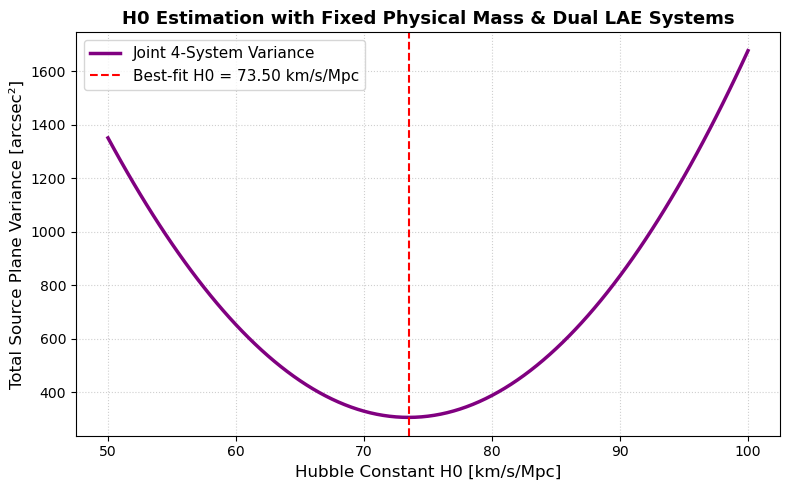

In [15]:
# ===========================================================================
# HUBBLE CONSTANT (H0) ESTIMATION WITH FIXED PHYSICAL MASS & DUAL LAE SYSTEMS
# ===========================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.LensModel.lens_model import LensModel

# ---------------------------------------------------------------------------
# 1. LOAD AND SEPARATE DATA INTO 4 DISTINCT SOURCE SYSTEMS
# ---------------------------------------------------------------------------
# Load the Lyman-Alpha Emitter dataset
lae_df = pd.read_csv('laes_z6.csv')

# Separate LAE entries into System 1 (z > 6.5) and System 2 (z < 6.5)
lae_sys1 = lae_df[lae_df['Z'] > 6.5].reset_index(drop=True)  # lae_6_1, lae_6_2
lae_sys2 = lae_df[lae_df['Z'] < 6.5].reset_index(drop=True)  # lae_6_3, lae_6_4, lae_6_5

# Convert sky coordinates (RA, DEC) to relative arcseconds for each LAE system
x_lae1, y_lae1 = to_arcsec(lae_sys1['RA'], lae_sys1['DEC'])
z_lae1 = lae_sys1['Z'].mean()  # z ~ 6.602

x_lae2, y_lae2 = to_arcsec(lae_sys2['RA'], lae_sys2['DEC'])
z_lae2 = lae_sys2['Z'].mean()  # z ~ 6.099

print("\n" + "="*50 + "\n=== LOADED SOURCE SYSTEMS ===" + "\n" + "="*50)
print(f"System 1 (z = 1.412):     5 images")
print(f"System 2 (z = 1.407):     6 images")
print(f"LAE System 1 (z = {z_lae1:.3f}): {len(lae_sys1)} images ({', '.join(lae_sys1['ID'])})")
print(f"LAE System 2 (z = {z_lae2:.3f}): {len(lae_sys2)} images ({', '.join(lae_sys2['ID'])})")

# ---------------------------------------------------------------------------
# 2. HELPER TO SCALE ANGULAR DEFLECTIONS (PRESERVING PHYSICAL MASS M_sun)
# ---------------------------------------------------------------------------
def get_scaled_kwargs_lens(opt_params, h0_candidate, h0_fiducial=70.0):
    """
    Scales the optimal angular parameters (alpha_Rs, k_eff) proportionally
    with H0 so that the underlying physical mass (M_sun) derived from
    lenstronomy_code.docx remains strictly fixed across cosmological models.
    """
    scale_factor = h0_candidate / h0_fiducial
    kwargs_base = get_kwargs_lens(opt_params)
    kwargs_scaled = []

    for kw in kwargs_base:
        kw_s = kw.copy()
        if 'alpha_Rs' in kw_s:
            kw_s['alpha_Rs'] *= scale_factor
        if 'k_eff' in kw_s:
            kw_s['k_eff'] *= scale_factor
        kwargs_scaled.append(kw_s)

    return kwargs_scaled

# ---------------------------------------------------------------------------
# 3. OBJECTIVE FUNCTION FOR MULTI-PLANE SOURCE VARIANCE
# ---------------------------------------------------------------------------
def compute_joint_source_spread_fixed_mass(h0_candidate, opt_params, h0_fiducial=70.0):
    """
    Computes source plane coordinate variance across all 4 independent source systems.
    """
    trial_cosmo = FlatLambdaCDM(H0=h0_candidate, Om0=0.3, Ob0=0.05)
    kwargs_lens_scaled = get_scaled_kwargs_lens(opt_params, h0_candidate, h0_fiducial)

    # Instantiate LensModels for all 4 distinct source plane redshifts
    lm_s1  = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.412,  cosmo=trial_cosmo)
    lm_s2  = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.407,  cosmo=trial_cosmo)
    lm_lae1 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae1, cosmo=trial_cosmo)
    lm_lae2 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae2, cosmo=trial_cosmo)

    # Ray-shoot observed image coordinates back to their respective source planes
    src1_ra, src1_dec   = lm_s1.ray_shooting(x_img1, y_img1, kwargs_lens_scaled)
    src2_ra, src2_dec   = lm_s2.ray_shooting(x_img2, y_img2, kwargs_lens_scaled)
    lae1_ra, lae1_dec   = lm_lae1.ray_shooting(x_lae1, y_lae1, kwargs_lens_scaled)
    lae2_ra, lae2_dec   = lm_lae2.ray_shooting(x_lae2, y_lae2, kwargs_lens_scaled)

    # Compute source plane coordinate variance for each system independently
    var1   = np.sum((src1_ra - np.mean(src1_ra))**2 + (src1_dec - np.mean(src1_dec))**2)
    var2   = np.sum((src2_ra - np.mean(src2_ra))**2 + (src2_dec - np.mean(src2_dec))**2)
    var_l1 = np.sum((lae1_ra - np.mean(lae1_ra))**2 + (lae1_dec - np.mean(lae1_dec))**2)
    var_l2 = np.sum((lae2_ra - np.mean(lae2_ra))**2 + (lae2_dec - np.mean(lae2_dec))**2)

    return var1 + var2 + var_l1 + var_l2

# ---------------------------------------------------------------------------
# 4. H0 GRID SEARCH (50 TO 100 km/s/Mpc)
# ---------------------------------------------------------------------------
print("\n" + "="*50 + "\n=== RUNNING H0 GRID SEARCH (FIXED PHYSICAL MASS) ===" + "\n" + "="*50)

h0_grid = np.linspace(50.0, 100.0, 101)
joint_spreads = []

for h0_test in h0_grid:
    score = compute_joint_source_spread_fixed_mass(h0_test, res_opt.x, h0_fiducial=70.0)
    joint_spreads.append(score)

joint_spreads = np.array(joint_spreads)
best_h0 = h0_grid[np.argmin(joint_spreads)]

print(f"Optimal Estimated Hubble Constant (H0): {best_h0:.2f} km/s/Mpc")
print(f"Minimum Total Source Plane Variance:   {np.min(joint_spreads):.5f} arcsec²")

# Plot H0 Variance Curve
plt.figure(figsize=(8, 5))
plt.plot(h0_grid, joint_spreads, color='purple', linewidth=2.5, label='Joint 4-System Variance')
plt.axvline(best_h0, color='red', linestyle='--', label=f'Best-fit H0 = {best_h0:.2f} km/s/Mpc')
plt.xlabel('Hubble Constant H0 [km/s/Mpc]', fontsize=12)
plt.ylabel('Total Source Plane Variance [arcsec²]', fontsize=12)
plt.title('H0 Estimation with Fixed Physical Mass & Dual LAE Systems', fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('h0_estimation_z6.png', dpi=300)
plt.show()

<>:95: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:95: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_4998/3191416509.py:95: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.title('Centroid Drift for Fixed Physical Mass Model ($H_0 = 50 \longrightarrow 100$)', fontsize=13, fontweight='bold')


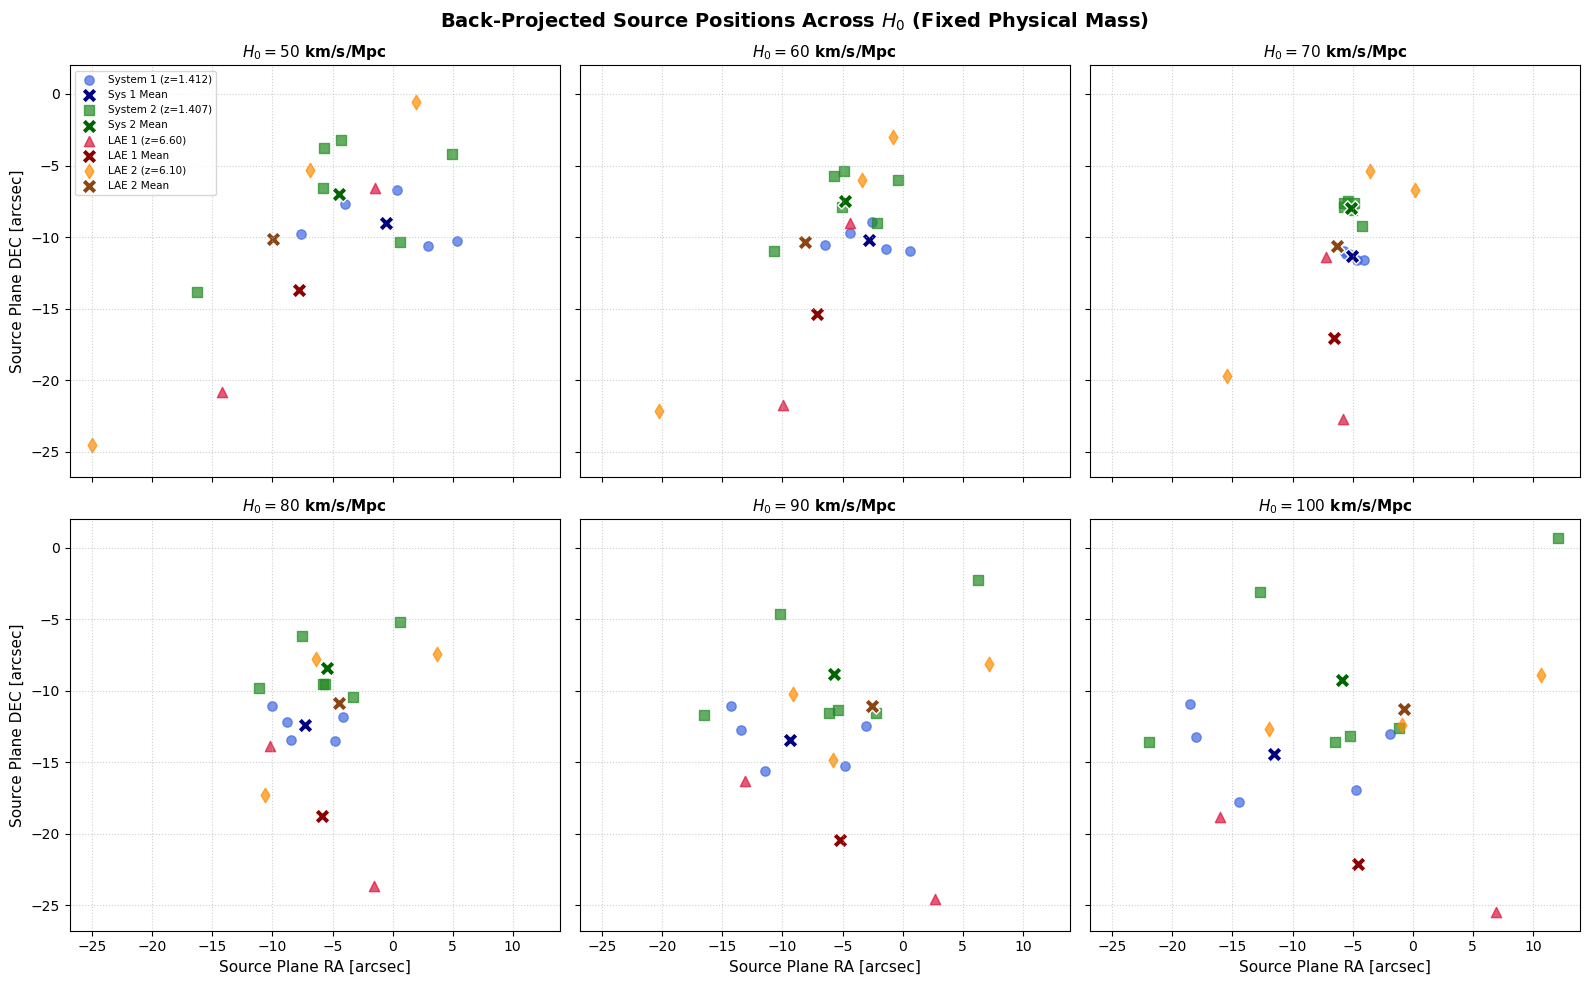

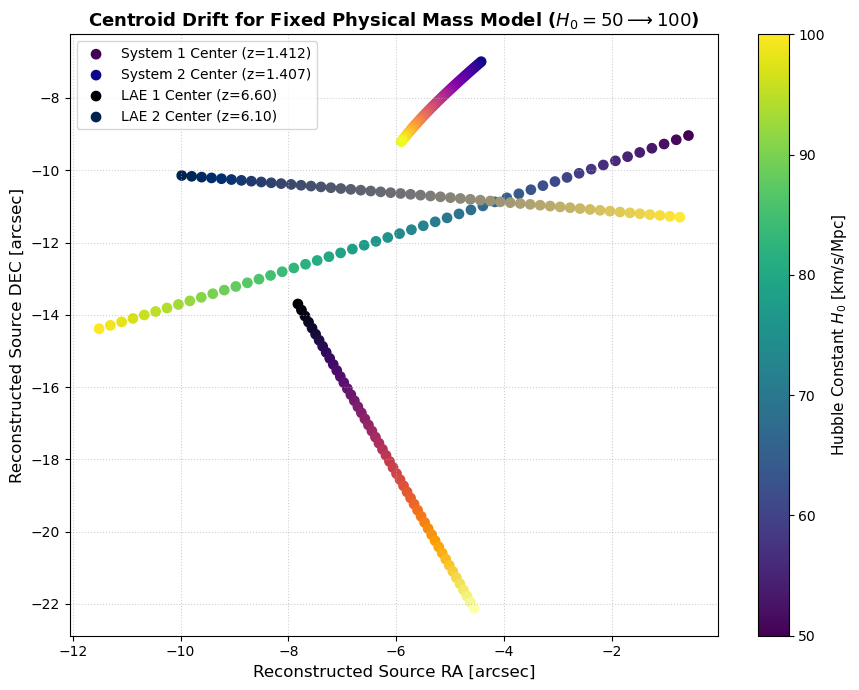

Generated 51 updated individual plots in directory: 'h0_fixed_mass_source_plots/'


In [17]:
# ---------------------------------------------------------------------------
# 5. DIAGNOSTIC VISUALIZATION 1: 2x3 SUBPLOT GRID (H0 = 50, 60, 70, 80, 90, 100)
# ---------------------------------------------------------------------------
h0_samples = [50, 60, 70, 80, 90, 100]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, h0_val in enumerate(h0_samples):
    ax = axes[idx]
    trial_cosmo = FlatLambdaCDM(H0=h0_val, Om0=0.3, Ob0=0.05)
    kwargs_lens_scaled = get_scaled_kwargs_lens(res_opt.x, h0_val, h0_fiducial=70.0)

    lm_s1  = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.412,  cosmo=trial_cosmo)
    lm_s2  = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.407,  cosmo=trial_cosmo)
    lm_lae1 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae1, cosmo=trial_cosmo)
    lm_lae2 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae2, cosmo=trial_cosmo)

    s1_ra, s1_dec   = lm_s1.ray_shooting(x_img1, y_img1, kwargs_lens_scaled)
    s2_ra, s2_dec   = lm_s2.ray_shooting(x_img2, y_img2, kwargs_lens_scaled)
    lae1_ra, lae1_dec = lm_lae1.ray_shooting(x_lae1, y_lae1, kwargs_lens_scaled)
    lae2_ra, lae2_dec = lm_lae2.ray_shooting(x_lae2, y_lae2, kwargs_lens_scaled)

    # Plot System 1
    ax.scatter(s1_ra, s1_dec, color='royalblue', marker='o', s=45, alpha=0.7, label='System 1 (z=1.412)')
    ax.scatter(np.mean(s1_ra), np.mean(s1_dec), color='navy', marker='X', s=120, edgecolor='white', label='Sys 1 Mean')

    # Plot System 2
    ax.scatter(s2_ra, s2_dec, color='forestgreen', marker='s', s=45, alpha=0.7, label='System 2 (z=1.407)')
    ax.scatter(np.mean(s2_ra), np.mean(s2_dec), color='darkgreen', marker='X', s=120, edgecolor='white', label='Sys 2 Mean')

    # Plot LAE System 1
    ax.scatter(lae1_ra, lae1_dec, color='crimson', marker='^', s=55, alpha=0.7, label=f'LAE 1 (z={z_lae1:.2f})')
    ax.scatter(np.mean(lae1_ra), np.mean(lae1_dec), color='darkred', marker='X', s=120, edgecolor='white', label='LAE 1 Mean')

    # Plot LAE System 2
    ax.scatter(lae2_ra, lae2_dec, color='darkorange', marker='d', s=55, alpha=0.7, label=f'LAE 2 (z={z_lae2:.2f})')
    ax.scatter(np.mean(lae2_ra), np.mean(lae2_dec), color='saddlebrown', marker='X', s=120, edgecolor='white', label='LAE 2 Mean')

    ax.set_title(f'$H_0 = {h0_val}$ km/s/Mpc', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

    if idx % 3 == 0:
        ax.set_ylabel('Source Plane DEC [arcsec]', fontsize=11)
    if idx >= 3:
        ax.set_xlabel('Source Plane RA [arcsec]', fontsize=11)
    if idx == 0:
        ax.legend(loc='best', fontsize=7.5)

plt.suptitle('Back-Projected Source Positions Across $H_0$ (Fixed Physical Mass)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('source_positions_grid_h0_fixed_mass.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------
# 6. DIAGNOSTIC VISUALIZATION 2: CENTROID DRIFT TRAJECTORY MAP (H0 = 50 TO 100)
# ---------------------------------------------------------------------------
h0_range = np.arange(50, 101, 1)
m_s1, m_s2, m_lae1, m_lae2 = [], [], [], []

for h0_val in h0_range:
    trial_cosmo = FlatLambdaCDM(H0=h0_val, Om0=0.3, Ob0=0.05)
    kwargs_lens_scaled = get_scaled_kwargs_lens(res_opt.x, h0_val, h0_fiducial=70.0)

    lm_s1   = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.412,  cosmo=trial_cosmo)
    lm_s2   = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.407,  cosmo=trial_cosmo)
    lm_lae1 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae1, cosmo=trial_cosmo)
    lm_lae2 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae2, cosmo=trial_cosmo)

    s1_ra, s1_dec   = lm_s1.ray_shooting(x_img1, y_img1, kwargs_lens_scaled)
    s2_ra, s2_dec   = lm_s2.ray_shooting(x_img2, y_img2, kwargs_lens_scaled)
    lae1_ra, lae1_dec = lm_lae1.ray_shooting(x_lae1, y_lae1, kwargs_lens_scaled)
    lae2_ra, lae2_dec = lm_lae2.ray_shooting(x_lae2, y_lae2, kwargs_lens_scaled)

    m_s1.append([np.mean(s1_ra), np.mean(s1_dec)])
    m_s2.append([np.mean(s2_ra), np.mean(s2_dec)])
    m_lae1.append([np.mean(lae1_ra), np.mean(lae1_dec)])
    m_lae2.append([np.mean(lae2_ra), np.mean(lae2_dec)])

m_s1_arr   = np.array(m_s1)
m_s2_arr   = np.array(m_s2)
m_lae1_arr = np.array(m_lae1)
m_lae2_arr = np.array(m_lae2)

plt.figure(figsize=(9, 7))
sc1 = plt.scatter(m_s1_arr[:, 0],   m_s1_arr[:, 1],   c=h0_range, cmap='viridis', label='System 1 Center (z=1.412)', s=45)
sc2 = plt.scatter(m_s2_arr[:, 0],   m_s2_arr[:, 1],   c=h0_range, cmap='plasma',  label='System 2 Center (z=1.407)', s=45)
sc3 = plt.scatter(m_lae1_arr[:, 0], m_lae1_arr[:, 1], c=h0_range, cmap='inferno', label=f'LAE 1 Center (z={z_lae1:.2f})', s=45)
sc4 = plt.scatter(m_lae2_arr[:, 0], m_lae2_arr[:, 1], c=h0_range, cmap='cividis', label=f'LAE 2 Center (z={z_lae2:.2f})', s=45)

cbar = plt.colorbar(sc1)
cbar.set_label('Hubble Constant $H_0$ [km/s/Mpc]', fontsize=11)
plt.xlabel('Reconstructed Source RA [arcsec]', fontsize=12)
plt.ylabel('Reconstructed Source DEC [arcsec]', fontsize=12)
plt.title('Centroid Drift for Fixed Physical Mass Model ($H_0 = 50 \longrightarrow 100$)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('source_center_drift_vs_h0_fixed_mass.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------
# 7. DIAGNOSTIC VISUALIZATION 3: EXPORT 51 INDIVIDUAL PLOTS
# ---------------------------------------------------------------------------
output_dir = "h0_fixed_mass_source_plots"
os.makedirs(output_dir, exist_ok=True)

for h0_val in h0_range:
    trial_cosmo = FlatLambdaCDM(H0=h0_val, Om0=0.3, Ob0=0.05)
    kwargs_lens_scaled = get_scaled_kwargs_lens(res_opt.x, h0_val, h0_fiducial=70.0)

    lm_s1   = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.412,  cosmo=trial_cosmo)
    lm_s2   = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=1.407,  cosmo=trial_cosmo)
    lm_lae1 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae1, cosmo=trial_cosmo)
    lm_lae2 = LensModel(lens_model_list=lens_model_list, lens_redshift_list=lens_redshift_list, multi_plane=True, z_source=z_lae2, cosmo=trial_cosmo)

    s1_ra, s1_dec   = lm_s1.ray_shooting(x_img1, y_img1, kwargs_lens_scaled)
    s2_ra, s2_dec   = lm_s2.ray_shooting(x_img2, y_img2, kwargs_lens_scaled)
    lae1_ra, lae1_dec = lm_lae1.ray_shooting(x_lae1, y_lae1, kwargs_lens_scaled)
    lae2_ra, lae2_dec = lm_lae2.ray_shooting(x_lae2, y_lae2, kwargs_lens_scaled)

    plt.figure(figsize=(7, 6))
    plt.scatter(s1_ra, s1_dec, color='royalblue', s=40, label='System 1 (z=1.412)')
    plt.scatter(np.mean(s1_ra), np.mean(s1_dec), color='navy', marker='X', s=120, label='Sys 1 Mean')

    plt.scatter(s2_ra, s2_dec, color='forestgreen', s=40, label='System 2 (z=1.407)')
    plt.scatter(np.mean(s2_ra), np.mean(s2_dec), color='darkgreen', marker='X', s=120, label='Sys 2 Mean')

    plt.scatter(lae1_ra, lae1_dec, color='crimson', s=50, label=f'LAE 1 (z={z_lae1:.2f})')
    plt.scatter(np.mean(lae1_ra), np.mean(lae1_dec), color='darkred', marker='X', s=120, label='LAE 1 Mean')

    plt.scatter(lae2_ra, lae2_dec, color='darkorange', s=50, label=f'LAE 2 (z={z_lae2:.2f})')
    plt.scatter(np.mean(lae2_ra), np.mean(lae2_dec), color='saddlebrown', marker='X', s=120, label='LAE 2 Mean')

    plt.xlabel('Source Plane RA [arcsec]', fontsize=11)
    plt.ylabel('Source Plane DEC [arcsec]', fontsize=11)
    plt.title(f'Source Positions at $H_0 = {h0_val}$ km/s/Mpc (Fixed $M_\\odot$)', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', fontsize=8.5)
    plt.tight_layout()

    plt.savefig(os.path.join(output_dir, f'source_pos_fixed_mass_H0_{h0_val}.png'), dpi=150)
    plt.close()

print(f"Generated 51 updated individual plots in directory: '{output_dir}/'")